In [1]:
!pip install -q kagglehub

In [2]:
import kagglehub
p = kagglehub.dataset_download("thoughtvector/customer-support-on-twitter")
p

100%|██████████| 169M/169M [00:02<00:00, 68.3MB/s]

Extracting files...


'/root/.cache/kagglehub/datasets/thoughtvector/customer-support-on-twitter/versions/10'

Ccылка на датасет, а также инструкцию по скачке:
https://www.kaggle.com/datasets/thoughtvector/customer-support-on-twitter

In [6]:
import pandas as pd
data = pd.read_csv(f'{p}/twcs/twcs.csv')
data.shape

(2811774, 7)

In [7]:
data.head()

,tweet_id,author_id,inbound,created_at,text,response_tweet_id,in_response_to_tweet_id
0,1,sprintcare,False,Tue Oct 31 22:10:47 +0000 2017,@115712 I understand. I would like to assist y...,2,3.0
1,2,115712,True,Tue Oct 31 22:11:45 +0000 2017,@sprintcare and how do you propose we do that,NaN,1.0
2,3,115712,True,Tue Oct 31 22:08:27 +0000 2017,@sprintcare I have sent several private messag...,1,4.0
3,4,sprintcare,False,Tue Oct 31 21:54:49 +0000 2017,@115712 Please send us a Private Message so th...,3,5.0
4,5,115712,True,Tue Oct 31 21:49:35 +0000 2017,@sprintcare I did.,4,6.0


In [8]:
comp = data[data['inbound'] == False]['author_id'].value_counts()
comp.head(30)
# inbound это входящее/исходящее обрашение
# author_idпри неправде(флаг) это компания от которой исходящее обращение

,count
author_id,
AmazonHelp,169840
AppleSupport,106860
Uber_Support,56270
SpotifyCares,43265
Delta,42253
Tesco,38573
AmericanAir,36764
TMobileHelp,34317
comcastcares,33031


In [9]:
mes_comp = data[data['inbound'] == False]
mes_client = data[data['inbound'] == True]
mes_client.head()

,tweet_id,author_id,inbound,created_at,text,response_tweet_id,in_response_to_tweet_id
1,2,115712,True,Tue Oct 31 22:11:45 +0000 2017,@sprintcare and how do you propose we do that,NaN,1.0
2,3,115712,True,Tue Oct 31 22:08:27 +0000 2017,@sprintcare I have sent several private messag...,1,4.0
4,5,115712,True,Tue Oct 31 21:49:35 +0000 2017,@sprintcare I did.,4,6.0
6,8,115712,True,Tue Oct 31 21:45:10 +0000 2017,@sprintcare is the worst customer service,"9,6,10",NaN
8,12,115713,True,Tue Oct 31 22:04:47 +0000 2017,@sprintcare You gonna magically change your co...,"11,13,14",15.0


In [10]:
# проверка сколько дублей tweet_id у клиента и у in_response_to_tweet_id у агента
print('дублей tweet_id у клиента:', mes_client['tweet_id'].duplicated().sum())
print('дублей in_response_to_tweet_id у агента:', mes_comp['in_response_to_tweet_id'].duplicated().sum())
print('всего клиентских твитов:', len(mes_client))
print('уникальных tweet_id у клиента:', mes_client['tweet_id'].nunique())

дублей tweet_id у клиента: 0
дублей in_response_to_tweet_id у агента: 104679
всего клиентских твитов: 1537843
уникальных tweet_id у клиента: 1537843


In [14]:
# убираем дубли по tweet_id преед соединением, иначе мердж дает декартово произведение
# и склеивает между собой не связанные друг с другом пары
cli_uni = mes_client.drop_duplicates(subset=['tweet_id'])[['tweet_id', 'text']]
comp_uni = mes_comp.drop_duplicates(subset=['in_response_to_tweet_id'])
pairs = comp_uni.merge(cli_uni,
                              left_on='in_response_to_tweet_id', right_on='tweet_id',
                              suffixes=('_agent', '_client'))
pairs = pairs[['text_client', 'text_agent']]
pairs.columns = ['input_text', 'target_text']
pairs.head()

,input_text,target_text
0,@sprintcare I have sent several private messag...,@115712 I understand. I would like to assist y...
1,@sprintcare I did.,@115712 Please send us a Private Message so th...
2,@sprintcare is the worst customer service,@115712 Can you please send us a private messa...
3,@sprintcare You gonna magically change your co...,@115713 This is saddening to hear. Please shoo...
4,@sprintcare Since I signed up with you....Sinc...,@115713 We understand your concerns and we'd l...


In [16]:
pairs.shape

(1164365, 2)

In [17]:
import re
def f(a):
    a = re.sub(r'@\w+', '', a)
    a = re.sub(r'http\S+', '', a)
    a = a.strip()
    return a
pairs['input_text']  = pairs['input_text'].apply(f)
pairs['target_text'] = pairs['target_text'].apply(f)
pairs.head()

,input_text,target_text
0,I have sent several private messages and no on...,I understand. I would like to assist you. We w...
1,I did.,Please send us a Private Message so that we ca...
2,is the worst customer service,"Can you please send us a private message, so t..."
3,You gonna magically change your connectivity f...,This is saddening to hear. Please shoot us a D...
4,Since I signed up with you....Since day 1,We understand your concerns and we'd like for ...


In [18]:
pairs = pairs[pairs['input_text'].str.len()  > 0]
pairs = pairs[pairs['target_text'].str.len() > 0]
pairs = pairs[pairs['input_text'].str.len()  >= 5]
pairs = pairs[pairs['target_text'].str.len() >= 5]
pairs = pairs.drop_duplicates()
pairs = pairs.reset_index(drop=True)
pairs.shape #пар после читски

(1145254, 2)

In [19]:
#еда для твиттера для длины текстов, топ компаний
import matplotlib.pyplot as plt
pairs['input_len']  = pairs['input_text'].str.len()
pairs['target_len'] = pairs['target_text'].str.len()
print(pairs[['input_len','target_len']].describe())

          input_len    target_len
count  1.145254e+06  1.145254e+06
mean   9.768526e+01  1.015145e+02
std    5.409215e+01  4.343182e+01
min    5.000000e+00  5.000000e+00
25%    5.800000e+01  7.400000e+01
50%    9.600000e+01  9.900000e+01
75%    1.260000e+02  1.220000e+02
max    2.960000e+02  2.990000e+02


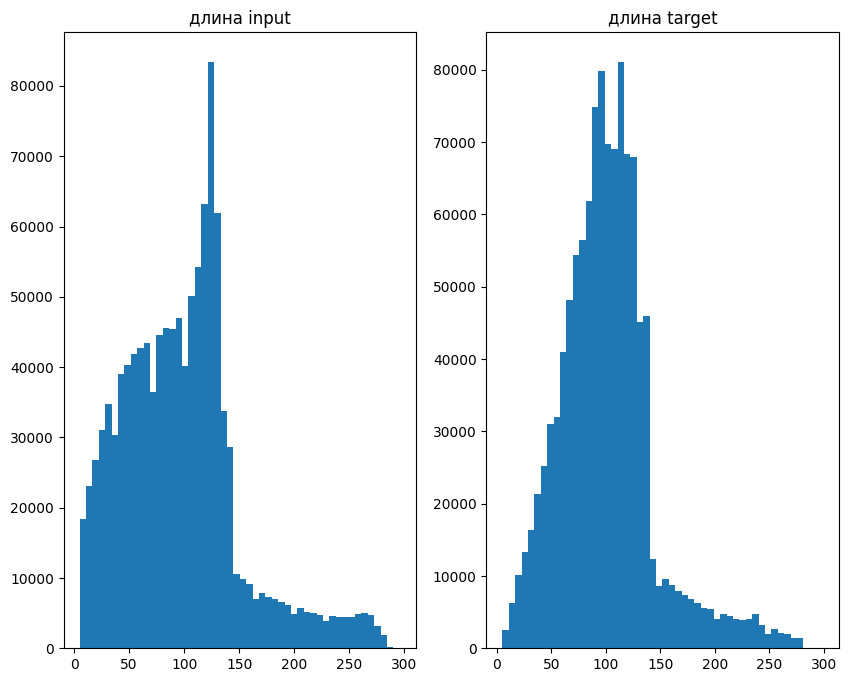

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(10,8))
axes[0].hist(pairs['input_len'].clip(upper=300), bins=50)
axes[0].set_title('длина input')
axes[1].hist(pairs['target_len'].clip(upper=300), bins=50)
axes[1].set_title('длина target')
plt.show()

на графиках видно что множетсво текстов в районе 100-150 символов, что для нс очень хорошо, я установилаи max_length=128 токенов и получсается, что он покрывает основную массу данных. хвост до 300 символов - некоторая часть примеров, они обрежутся, но их мало и поэтому это не критично

In [21]:
# оставляем тексты на английском, потому что Т5 наточена на английский
pairs = pairs[pairs['input_text'].apply(lambda x: sum(c.isascii() for c in x) / max(len(x),1) > 0.9)]
pairs = pairs[pairs['target_text'].apply(lambda x: sum(c.isascii() for c in x) / max(len(x),1) > 0.9)]
pairs = pairs.reset_index(drop=True)
pairs.shape

(1124158, 4)

In [22]:
# убираем слишком длинные тексты, потому что там склеенные твиты при парсинге
pairs = pairs[pairs['input_text'].str.len()  <= 500]
pairs = pairs[pairs['target_text'].str.len() <= 500]
pairs = pairs.reset_index(drop=True)
pairs.shape

(1124158, 4)

In [23]:
# убираем пары где ответ агента совпадает с сообщением клиента, это просто баг при. парсинге
pairs = pairs[pairs['input_text'] != pairs['target_text']]
pairs = pairs.reset_index(drop=True)
pairs.shape

(1124157, 4)

In [25]:
# слова маркеры намерения уйти или жалобы или недовольства, как раз то, что то относится к retention
ret_words = [
    'cancel', 'cancellation', 'terminate', 'termination',
    'leave', 'leaving', 'quit', 'unsubscribe',
    'too expensive', 'cheaper', 'competitor', 'switch',
    'disappointed', 'unhappy', 'dissatisfied', 'frustrated',
    'better offer', 'discount', 'refund', 'close account'
]
pattern = '|'.join(ret_words)
mask = pairs['input_text'].str.lower().str.contains(pattern, na=False)
mask.sum(), (~mask).sum() #ret rows, other

(np.int64(82852), np.int64(1041305))

In [26]:
# остальные строки исключаем, тк в них нет намерения уйти/жалобы/недовольства,
# это диалоги про трекинг заказов, технические вопросы и тд, не относится к retention
pairs = pairs[mask].drop(columns=['input_len','target_len']).reset_index(drop=True)
pairs['source'] = 'twitter'
pairs.shape

(82852, 3)

In [28]:
from datasets import load_dataset
ds = load_dataset('bitext/Bitext-customer-support-llm-chatbot-training-dataset')
bitext = ds['train'].to_pandas()
bitext.shape

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/11.9k [00:00<?, ?B/s]

Bitext_Sample_Customer_Support_Training_(…):   0%|          | 0.00/19.2M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/26872 [00:00<?, ? examples/s]

(26872, 5)

In [29]:
bitext.head()

,flags,instruction,category,intent,response
0,B,question about cancelling order {{Order Number}},ORDER,cancel_order,I've understood you have a question regarding ...
1,BQZ,i have a question about cancelling oorder {{Or...,ORDER,cancel_order,I've been informed that you have a question ab...
2,BLQZ,i need help cancelling puchase {{Order Number}},ORDER,cancel_order,I can sense that you're seeking assistance wit...
3,BL,I need to cancel purchase {{Order Number}},ORDER,cancel_order,I understood that you need assistance with can...
4,BCELN,"I cannot afford this order, cancel purchase {{...",ORDER,cancel_order,I'm sensitive to the fact that you're facing f...


In [31]:
# распределение по интентам и длины
print(bitext['intent'].value_counts())
bitext['input_len']  = bitext['instruction'].str.len()
bitext['target_len'] = bitext['response'].str.len()
print(bitext[['input_len','target_len']].describe())

intent
contact_customer_service    1000
complaint                   1000
check_invoice               1000
switch_account              1000
edit_account                1000
contact_human_agent          999
check_payment_methods        999
delivery_period              999
newsletter_subscription      999
get_invoice                  999
payment_issue                999
registration_problems        999
cancel_order                 998
place_order                  998
track_refund                 998
change_order                 997
set_up_shipping_address      997
check_refund_policy          997
create_account               997
get_refund                   997
review                       997
delivery_options             995
delete_account               995
recover_password             995
track_order                  995
change_shipping_address      973
check_cancellation_fee       950
Name: count, dtype: int64
          input_len    target_len
count  26872.000000  26872.000000
mean    

In [33]:
# интенты с сигналом оттока: отмена, жалоба, эскалация, ростальные (track_order, faq и тд) не про retention
ret_intents = ['cancel_order', 'complaint', 'contact_human_agent', 'get_refund', 'track_refund']
bitext = bitext[bitext['intent'].isin(ret_intents)].reset_index(drop=True)
bitext.shape

(4992, 7)

In [34]:
bitext = bitext[['instruction', 'response']]
bitext.columns = ['input_text', 'target_text']
bitext = bitext.apply(lambda col: col.apply(f))
bitext.head()

,input_text,target_text
0,question about cancelling order {{Order Number}},I've understood you have a question regarding ...
1,i have a question about cancelling oorder {{Or...,I've been informed that you have a question ab...
2,i need help cancelling puchase {{Order Number}},I can sense that you're seeking assistance wit...
3,I need to cancel purchase {{Order Number}},I understood that you need assistance with can...
4,"I cannot afford this order, cancel purchase {{...",I'm sensitive to the fact that you're facing f...


In [35]:
# чистка длина, дубликаты, совпадение input/target
bitext = bitext[bitext['input_text'].str.len()  >= 5]
bitext = bitext[bitext['target_text'].str.len() >= 5]
bitext = bitext[bitext['input_text'].str.len()  <= 500]
bitext = bitext[bitext['target_text'].str.len() <= 500]
bitext = bitext[bitext['input_text'] != bitext['target_text']]
bitext = bitext.drop_duplicates()
bitext = bitext.reset_index(drop=True)
bitext['source'] = 'bitext'
bitext.shape

(1657, 3)

In [36]:
# объединяем оба источника. битекст добавляет чистые возвратные кейсы с разметкой intent,
# твиттер добавляет объеи и разговорную стилистику
pairs = pd.concat([pairs, bitext], ignore_index=True)
pairs = pairs.drop_duplicates(subset=['input_text','target_text']).reset_index(drop=True)
print(pairs['source'].value_counts())
pairs.shape

source
twitter    82852
bitext      1657
Name: count, dtype: int64


(84509, 3)

In [37]:
pairs[['input_text','target_text','source']].to_csv('retention_dialogs.csv', index=False)

In [38]:
# тут мы смотрим случайные пары, должны быть логически связаны
for i in pairs.sample(5, random_state=1).index:
    print('клиент:', pairs.loc[i, 'input_text'])
    print('агент: ', pairs.loc[i, 'target_text'])
    print()

клиент: hello spotify. My family subscription has been terminated and when i renew back it renew to the personal subscription.
агент:  Hi there! Can you DM us your account's email address or username? We'll take a look backstage /NQ

клиент: I’m a bit taken aback that you’ve cancelled my delivery without any reason or a new date!
агент:  .   Could you please DM me and I will look into that for you.  Thanks - Kate

клиент: How bout discounting my flights since there is something wrong in first class every single flight.  Ridiculous
агент:  We're truly sorry to hear this. Please be sure to let our Baggage Service Office know about the damage.

клиент: my connection leaves Westbury at 11:11. What am I meant to do?
агент:  Hi Nicky. Apologies for the delay. Where are you travelling to please? Phil.

клиент: shitty day w a shitty mood .. hours cut, bank meeting, 2 lyft drivers cancelled, forgot my hw, called out in class by prof. ... fuck me
агент:  Hey there. If there is a specific issue t

пары в общем случсае лостаточно логичные, видно, что агент реагирует на проблему клиента, но также хочу отметить, что последний пример (клиент жалуется на плохой день) не про ретеншен вообще, это шум который фильтр на возврат клиента не сработал, потмоу что нет ключ слов.

еще видно, что агентские ответы очень шаблонные "DM us your email" почти везде модель именно это и выучила